In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import OpenAI
from typing import TypedDict

In [8]:
# right now i dont have any api key so this wont run 
model=OpenAI()

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [3]:
#create class
class LLMState(TypedDict):
    question:str
    ans:str


In [52]:
a=LLMState({"question":"how are you","ans":7})

In [53]:
a

{'question': 'how are you', 'ans': 7}

In [4]:
def llm_qa(state:LLMState) ->LLMState:
    #extract the question from the state
    ques=state['question']
    #from a prompt
    prompt=f"answer the following {ques}"
    # ask the question to LLM
    answer=model.invoke(prompt).content
    #update the state
    state["answer"]=answer

    return state

In [6]:
# create our graph
graph=StateGraph(LLMState)

# add nodes
graph.add_node("llm_qa",llm_qa)

#add edges
graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)

#compile ,this give an runnable object 
workflow=graph.compile()



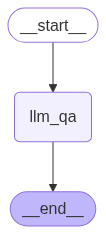

In [7]:
workflow

In [ ]:
#Executaion
workflow.invoke({})